In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/train.csv')
print("Shape:", df.shape)

Shape: (1460, 81)


In [2]:
# Columns with more than 50% missing values are useless
thresh = len(df) * 0.5
df = df.dropna(axis=1, thresh=thresh)
print("Shape after dropping high missing columns:", df.shape)

Shape after dropping high missing columns: (1460, 76)


In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
print("Missing numerical values:", df[num_cols].isnull().sum().sum())

Missing numerical values: 0


In [4]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
print("Missing categorical values:", df[cat_cols].isnull().sum().sum())

Missing categorical values: 0


In [5]:
print("Total missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)

Total missing values: 0
Shape: (1460, 76)


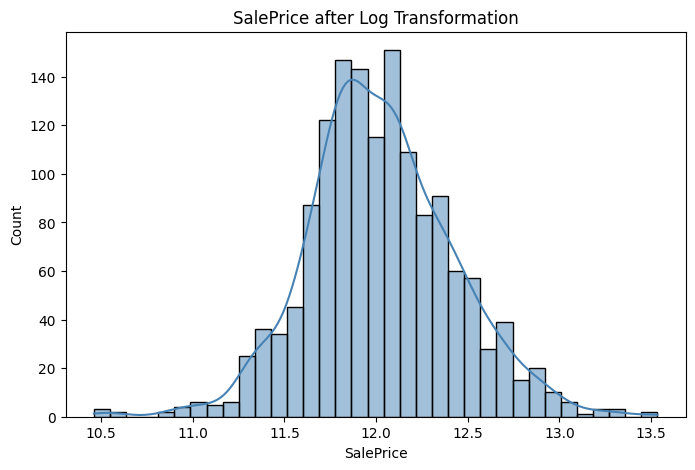

In [6]:
df['SalePrice'] = np.log1p(df['SalePrice'])

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True, color='steelblue')
plt.title('SalePrice after Log Transformation')
plt.show()

In [7]:
df.to_csv('../data/train_cleaned.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!
